In [1]:
import pandas as pd 
import sqlite3
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [3]:
commits = pd.read_sql(""" 
SELECT timestamp
FROM checker
WHERE uid LIKE "user_%"
""", conn)

In [4]:
commits['timestamp'] = pd.to_datetime(commits['timestamp'])

commits['date'] = commits['timestamp'].dt.date
commits['day_of_week'] = commits['timestamp'].dt.dayofweek
commits['hour'] = commits['timestamp'].dt.hour

In [5]:
weekend = commits[commits['day_of_week'].isin([5,6])].reset_index()
working_day = commits[~commits['day_of_week'].isin([5,6])].reset_index()

In [6]:
working_day.head()

,index,timestamp,date,day_of_week,hour
0,0,2020-04-17 05:19:02.744528,2020-04-17,4,5
1,1,2020-04-17 05:22:35.249331,2020-04-17,4,5
2,2,2020-04-17 05:22:45.549397,2020-04-17,4,5
3,3,2020-04-17 05:34:14.691200,2020-04-17,4,5
4,4,2020-04-17 05:34:24.422370,2020-04-17,4,5


In [7]:
workday_counts = working_day.groupby(['date', 'hour']).size().reset_index(name='commits')
weekend_counts = weekend.groupby(['date', 'hour']).size().reset_index(name='commits')

weekend_counts.head()

,date,hour,commits
0,2020-04-18,7,1
1,2020-04-18,13,5
2,2020-04-18,14,3
3,2020-04-18,15,25
4,2020-04-18,17,7


In [8]:
workday_counts[workday_counts['hour'] == 21]

,date,hour,commits
18,2020-04-22,21,3
28,2020-04-23,21,18
35,2020-04-27,21,2
52,2020-05-01,21,4
70,2020-05-05,21,1
80,2020-05-07,21,17
88,2020-05-08,21,8
100,2020-05-11,21,32
117,2020-05-12,21,22
130,2020-05-13,21,74


In [9]:
workday_counts = workday_counts.groupby('hour')['commits'].sum()
weekend_counts = weekend_counts.groupby('hour')['commits'].sum()

In [10]:
workday_counts.loc[21]

np.int64(292)

In [11]:
all_hours = pd.DataFrame({'hour':range(24)})

workday_full = all_hours.merge(workday_counts, on='hour', how='left')
weekend_full = all_hours.merge(weekend_counts, on='hour',how='left')

workday_full.fillna(0, inplace=True)
weekend_full.fillna(0, inplace=True)

In [12]:
workday_full.head(10)

,hour,commits
0,0,6.0
1,1,0.0
2,2,0.0
3,3,2.0
4,4,0.0
5,5,15.0
6,6,3.0
7,7,31.0
8,8,37.0
9,9,30.0


In [13]:
workday_hours = []
for _, row in workday_full.iterrows():
    workday_hours.extend([row['hour']] * int(row['commits']))

weekend_hours = []
for _, row in weekend_full.iterrows():
    weekend_hours.extend([row['hour']] * int(row['commits']))

In [14]:
workday_hours[:10]

[np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(3.0),
 np.float64(3.0),
 np.float64(5.0),
 np.float64(5.0)]

In [15]:
len(workday_hours)

2037

In [16]:
len(weekend_hours)

1170

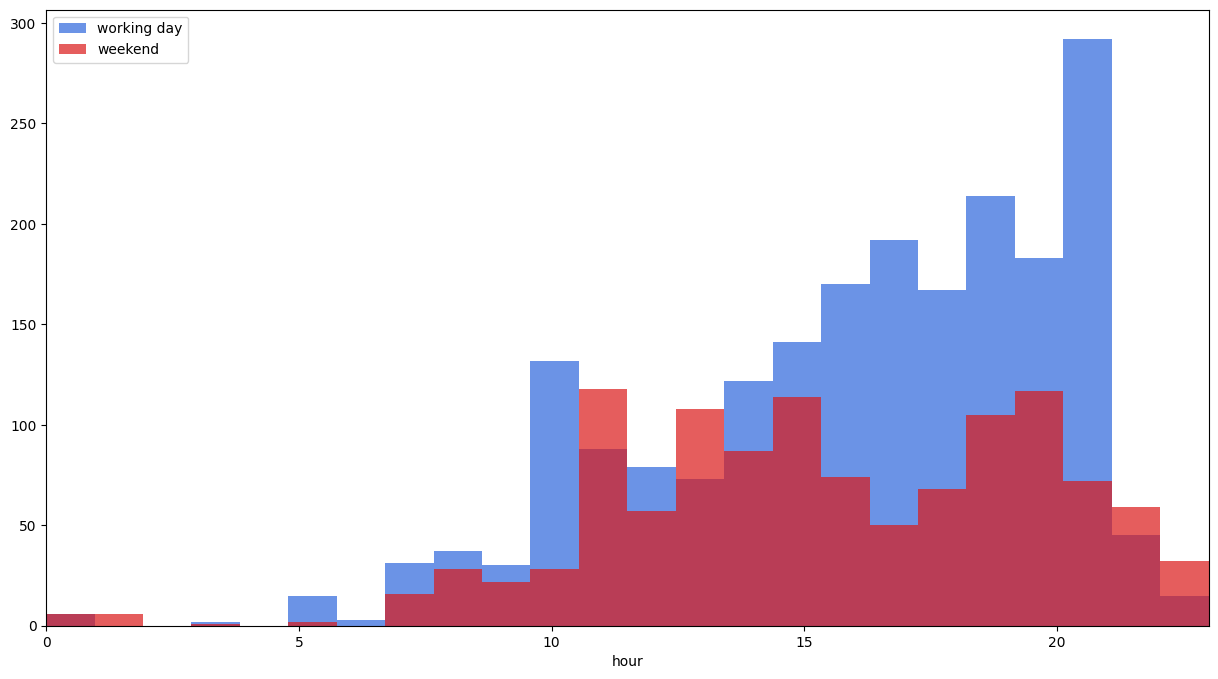

In [17]:
plt.figure(figsize=(15, 8))
plt.hist(workday_hours, bins=24, alpha=0.7, label='working day', color="#2D65DC", range=(0,23))
plt.hist(weekend_hours, bins=24, alpha=0.7, label='weekend', color="#DB1919", range=(0,23))
plt.xlabel('hour')
plt.legend()
plt.xlim(0,23)
plt.show()

Бывают ли часы, когда общее количество коммитов в выходные дни было выше, чем в рабочие дни?
- 11, 13, 22, 23

In [18]:
conn.close()